<a href="https://colab.research.google.com/github/tusharj23/ProteinBERT/blob/main/notebooks/Tape_Transformer_with_pretraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tape-proteins

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.5 MB/s eta 0:00:00


In [ ]:
!wget https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz

--2026-03-18 19:19:31--  https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 54.231.163.64, 52.217.117.88, 52.217.231.56, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|54.231.163.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 251794897 (240M) [application/x-tar]
Saving to: ‘secondary_structure.tar.gz’

secondary_structure 100%[===================>] 240.13M  38.9MB/s    in 6.6s    

2026-03-18 19:19:38 (36.5 MB/s) - ‘secondary_structure.tar.gz’ saved [251794897/251794897]



In [ ]:
!mkdir -p data
!tar -xzf secondary_structure.tar.gz -C data

Detected vocab size: 29

MODEL ARCHITECTURE

Layer                    Activation Volume        Params         
Input                    16x512                   0              
Embedding                (16, 512, 256)           7424           
LayerNorm                (16, 512, 256)           512            
PositionalEncoding       (16, 512, 256)           0              
TransformerEncoder       (16, 512, 256)           2108416        

Starting MLM Pretraining...

Pretrain Epoch 1 Loss 1.4956
Pretrain Epoch 2 Loss 1.4001
Pretrain Epoch 3 Loss 1.3888
Pretrain Epoch 4 Loss 1.3854
Pretrain Epoch 5 Loss 1.3797

Starting Fine-tuning...



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/25 | Train Loss 1.0071 | Train Acc 0.4911 | Val Loss 0.9876 | Val Acc 0.5079
Epoch 2/25 | Train Loss 0.9767 | Train Acc 0.5185 | Val Loss 0.9280 | Val Acc 0.5581
Epoch 3/25 | Train Loss 0.9097 | Train Acc 0.5720 | Val Loss 0.8772 | Val Acc 0.5936
Epoch 4/25 | Train Loss 0.8669 | Train Acc 0.6014 | Val Loss 0.8471 | Val Acc 0.6142
Epoch 5/25 | Train Loss 0.8494 | Train Acc 0.6128 | Val Loss 0.8274 | Val Acc 0.6246
Epoch 6/25 | Train Loss 0.8392 | Train Acc 0.6184 | Val Loss 0.8133 | Val Acc 0.6334
Epoch 7/25 | Train Loss 0.8314 | Train Acc 0.6229 | Val Loss 0.8091 | Val Acc 0.6367
Epoch 8/25 | Train Loss 0.8265 | Train Acc 0.6263 | Val Loss 0.8070 | Val Acc 0.6393
Epoch 9/25 | Train Loss 0.8199 | Train Acc 0.6302 | Val Loss 0.7983 | Val Acc 0.6420
Epoch 10/25 | Train Loss 0.8165 | Train Acc 0.6317 | Val Loss 0.8035 | Val Acc 0.6412
Epoch 11/25 | Train Loss 0.8121 | Train Acc 0.6344 | Val Loss 0.7969 | Val Acc 0.6424
Epoch 12/25 | Train Loss 0.8071 | Train Acc 0.6369 | Val Loss 0

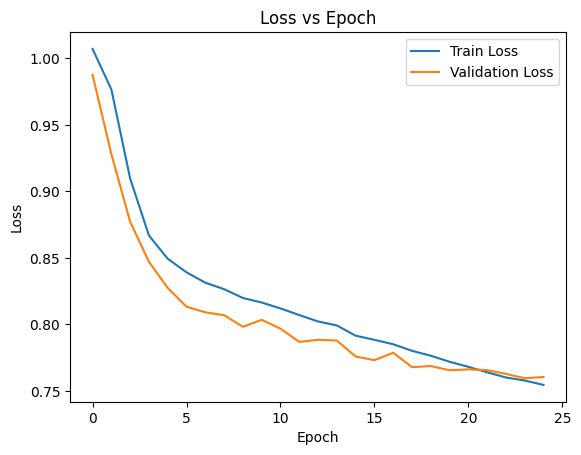

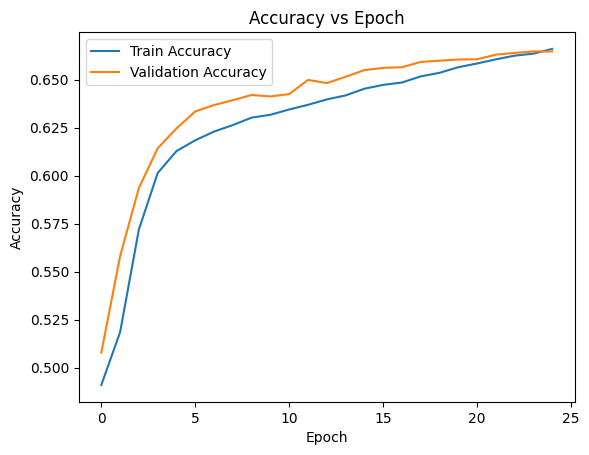

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import math
import matplotlib.pyplot as plt
import random
from tape.datasets import SecondaryStructureDataset

# Hyperparameters
LR = 1e-3
MAX_LEN = 512
BATCH_SIZE = 16
PRETRAIN_EPOCHS = 5
FINETUNE_EPOCHS = 25

d_model = 256
heads = 8
layers = 4
MASK_TOKEN = 28

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset Wrapper
class TapeDataset(Dataset):

    def __init__(self, split):

        self.dataset = SecondaryStructureDataset(
            data_path="./data",
            split=split
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        token_ids, input_mask, labels = self.dataset[idx]

        seq = torch.tensor(token_ids)
        label = torch.tensor(labels)

        seq = seq[:MAX_LEN]
        label = label[:MAX_LEN]

        if len(seq) < MAX_LEN:

            pad = MAX_LEN - len(seq)

            seq = torch.cat([seq, torch.zeros(pad).long()])
            label = torch.cat([label, torch.full((pad,), -1).long()])

        return seq, label



# Dataset Loading
train_dataset = TapeDataset("train")
valid_dataset = TapeDataset("valid")
test_dataset = TapeDataset("cb513")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Detect Vocabulary
max_token = 0
for i in range(500):
    token_ids, _, _ = train_dataset.dataset[i]
    max_token = max(max_token, max(token_ids))

VOCAB_SIZE = max_token + 1
print("Detected vocab size:", VOCAB_SIZE)

# Positional Encoding
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=1000):

        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000) / d_model)
        )

        pe[:,0::2] = torch.sin(position*div_term)
        pe[:,1::2] = torch.cos(position*div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):

        return x + self.pe[:,:x.size(1)]

# Transformer Model
class ProteinTransformer(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)

        self.norm = nn.LayerNorm(d_model)

        self.pos_encoding = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=heads,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers
        )

        self.mlm_head = nn.Linear(d_model, vocab_size)

        self.classifier = nn.Linear(d_model, 3)

    def forward(self, x):

        mask = (x == 0)

        x = self.embedding(x)
        x = self.norm(x)
        x = self.pos_encoding(x)

        x = self.encoder(x, src_key_padding_mask=mask)

        return x


model = ProteinTransformer(VOCAB_SIZE).to(device)

# Model Architecture Table
def print_model_table(model):

    x = torch.zeros(BATCH_SIZE, MAX_LEN).long().to(device)

    print("\nMODEL ARCHITECTURE\n")
    print("{:<25}{:<25}{:<15}".format("Layer","Activation Volume","Params"))

    print("{:<25}{:<25}{:<15}".format(
        "Input",
        f"{BATCH_SIZE}x{MAX_LEN}",
        "0"
    ))

    x = model.embedding(x)
    print("{:<25}{:<25}{:<15}".format(
        "Embedding",
        str(tuple(x.shape)),
        model.embedding.weight.numel()
    ))

    x = model.norm(x)
    params = sum(p.numel() for p in model.norm.parameters())

    print("{:<25}{:<25}{:<15}".format(
        "LayerNorm",
        str(tuple(x.shape)),
        params
    ))

    x = model.pos_encoding(x)

    print("{:<25}{:<25}{:<15}".format(
        "PositionalEncoding",
        str(tuple(x.shape)),
        "0"
    ))

    mask = torch.zeros(BATCH_SIZE,MAX_LEN).bool().to(device)

    x = model.encoder(x, src_key_padding_mask=mask)

    params = sum(p.numel() for p in model.encoder.parameters())

    print("{:<25}{:<25}{:<15}".format(
        "TransformerEncoder",
        str(tuple(x.shape)),
        params
    ))

print_model_table(model)

# MLM Masking Function
def mask_tokens(seq, mask_prob=0.15):

    labels = seq.clone()

    mask = torch.rand(seq.shape) < mask_prob

    seq[mask] = MASK_TOKEN

    labels[~mask] = -1

    return seq, labels


# Pretraining (Masked Language Model)
mlm_loss_fn = nn.CrossEntropyLoss(ignore_index=-1)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("\nStarting MLM Pretraining...\n")

for epoch in range(PRETRAIN_EPOCHS):

    model.train()
    total_loss = 0

    for seq, _ in train_loader:

        seq = seq.to(device)

        masked, labels = mask_tokens(seq.clone())

        masked = masked.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        rep = model(masked)

        logits = model.mlm_head(rep)

        loss = mlm_loss_fn(
            logits.view(-1,VOCAB_SIZE),
            labels.view(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Pretrain Epoch {epoch+1} Loss {total_loss/len(train_loader):.4f}")

# Fine-tuning
criterion = nn.CrossEntropyLoss(ignore_index=-1)

train_losses=[]
val_losses=[]
train_acc=[]
val_acc=[]

print("\nStarting Fine-tuning...\n")

for epoch in range(FINETUNE_EPOCHS):

    model.train()

    total_loss=0
    correct=0
    total=0

    for seq,label in train_loader:

        seq,label = seq.to(device),label.to(device)

        optimizer.zero_grad()

        rep = model(seq)

        output = model.classifier(rep)

        pred = torch.argmax(output,dim=-1)

        mask = label!=-1

        correct += ((pred==label)*mask).sum().item()
        total += mask.sum().item()

        loss = criterion(
            output.view(-1,3),
            label.view(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss/len(train_loader)
    train_accuracy = correct/total

    train_losses.append(train_loss)
    train_acc.append(train_accuracy)

    # Validation
    model.eval()

    total_loss=0
    correct=0
    total=0

    with torch.no_grad():

        for seq,label in valid_loader:

            seq,label = seq.to(device),label.to(device)

            rep = model(seq)

            output = model.classifier(rep)

            pred = torch.argmax(output,dim=-1)

            mask = label!=-1

            correct += ((pred==label)*mask).sum().item()
            total += mask.sum().item()

            loss = criterion(
                output.view(-1,3),
                label.view(-1)
            )

            total_loss += loss.item()

    val_loss = total_loss/len(valid_loader)
    val_accuracy = correct/total

    val_losses.append(val_loss)
    val_acc.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/{FINETUNE_EPOCHS} | "
        f"Train Loss {train_loss:.4f} | Train Acc {train_accuracy:.4f} | "
        f"Val Loss {val_loss:.4f} | Val Acc {val_accuracy:.4f}"
    )

# Test Evaluation
model.eval()

correct=0
total=0
loss_sum=0

with torch.no_grad():

    for seq,label in test_loader:

        seq,label = seq.to(device),label.to(device)

        rep = model(seq)

        output = model.classifier(rep)

        pred = torch.argmax(output,dim=-1)

        mask = label!=-1

        correct += ((pred==label)*mask).sum().item()
        total += mask.sum().item()

        loss = criterion(
            output.view(-1,3),
            label.view(-1)
        )

        loss_sum += loss.item()

test_loss = loss_sum/len(test_loader)
test_acc = correct/total

print("\nTest Loss:",test_loss)
print("Test Accuracy:",test_acc)

# Plots

plt.figure()
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Epoch")
plt.show()

plt.figure()
plt.plot(train_acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy vs Epoch")
plt.show()

In [ ]:
def run_custom_sequence(model):

    model.eval()


    print("CUSTOM SEQUENCE FLOW")


    # Given Sequence
    seq_str = "AAYPIEFTYPDGQNGEQGFQGAHFLAFG"
    label_str = "CCEEEEEEECCHHHHHHHHHHHHCCCC"


    # Mapping
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    aa_to_id = {aa: i+1 for i, aa in enumerate(amino_acids)}

    label_map = {"H": 0, "E": 1, "C": 2}
    inv_map = {0: "H", 1: "E", 2: "C"}

    # Convert to IDs
    seq_ids = [aa_to_id.get(a, 0) for a in seq_str]
    label_ids = [label_map[s] for s in label_str]

    print("Original Length:", len(seq_ids))

    seq = torch.tensor(seq_ids)
    label = torch.tensor(label_ids)


    # Padding
    if len(seq) < MAX_LEN:

        pad = MAX_LEN - len(seq)

        seq = torch.cat([seq, torch.zeros(pad).long()])
        label = torch.cat([
            label,
            torch.full((pad,), -1).long()
        ])

        print("After Padding Length:", len(seq))

    seq = seq.unsqueeze(0).to(device)
    label = label.unsqueeze(0).to(device)


    # Forward Pass
    print("\n--- Forward Pass ---")

    x = model.embedding(seq)
    print("Embedding Output:", x.shape)

    if hasattr(model, "norm"):
        x = model.norm(x)
        print("After LayerNorm:", x.shape)

    x = model.pos_encoding(x)
    print("After Positional Encoding:", x.shape)

    mask = (seq == 0)

    if hasattr(model, "transformer"):
        x = model.transformer(x, src_key_padding_mask=mask)
    else:
        x = model.encoder(x, src_key_padding_mask=mask)

    print("After Transformer:", x.shape)

    if hasattr(model, "classifier"):
        out = model.classifier(x)
    else:
        out = model.fc(x)

    print("Final Output:", out.shape)


    # Predictions
    pred = torch.argmax(out, dim=-1).squeeze().cpu().numpy()
    label = label.squeeze().cpu().numpy()

    # Remove padding safely
    clean_pred = []
    clean_label = []

    for p, l in zip(pred, label):
        if l != -1:
            clean_pred.append(int(p))
            clean_label.append(int(l))

    pred_str = "".join([inv_map[p] for p in clean_pred])
    true_str = "".join([inv_map[l] for l in clean_label])

    print("\n--- Results ---")
    print("Sequence: ", seq_str)
    print("True SS : ", true_str)
    print("Pred SS : ", pred_str)


run_custom_sequence(model)

CUSTOM SEQUENCE FLOW
Original Length: 28
After Padding Length: 512

--- Forward Pass ---
Embedding Output: torch.Size([1, 512, 256])
After LayerNorm: torch.Size([1, 512, 256])
After Positional Encoding: torch.Size([1, 512, 256])
After Transformer: torch.Size([1, 512, 256])
Final Output: torch.Size([1, 512, 3])

--- Results ---
Sequence:  AAYPIEFTYPDGQNGEQGFQGAHFLAFG
True SS :  CCEEEEEEECCHHHHHHHHHHHHCCCC
Pred SS :  CCCCCCCCCCCHHHHHHHHHHHHHHHH
